In [1]:


import numpy as np
import xarray as xr
import metpy.calc as mpcalc
import time
import os
import glob
from metpy.units import units
from typing import Tuple, List, Dict
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import signal, fft
import cmaps
# from pywk99.spectrum.spectrum import get_cross_spectrum

FIG_SAVE_DIR = "./figures/cross_spectrum/"

# 创建必要的目录
for d in [ FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)


EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

In [2]:
# ============ 快速加载850hPa散度数据 ============

def load_850hpa_divergence(experiment='cntl', data_dir='processed_data'):
    """
    快速加载已保存的850hPa散度数据
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    
    Returns:
    --------
    xr.DataArray
        散度数据
    
    Example:
    --------
    >>> div_cntl = load_850hpa_divergence('cntl')
    >>> div_p4k = load_850hpa_divergence('p4k')
    >>> div_4co2 = load_850hpa_divergence('4co2')
    """
    # 构建文件路径
    file_pattern = os.path.join(data_dir, f'divergence_850hpa_lev*_{experiment}.nc')
    files = glob.glob(file_pattern)
    
    if not files:
        raise FileNotFoundError(f"未找到实验 {experiment} 的散度数据文件: {file_pattern}")
    
    if len(files) > 1:
        print(f"⚠️ 找到多个文件，使用第一个: {files[0]}")
    
    file_path = files[0]
    print(f"📂 加载数据: {file_path}")
    
    # 加载数据
    ds = xr.open_dataset(file_path)
    div = ds['divergence']
    
    print(f"✅ 数据加载成功")
    print(f"   形状: {div.shape}")
    print(f"   维度: {div.dims}")
    print(f"   时间范围: {div.time.values[0]} to {div.time.values[-1]}")
    print(f"   空间范围: lat [{div.lat.min().values:.1f}, {div.lat.max().values:.1f}], "
          f"lon [{div.lon.min().values:.1f}, {div.lon.max().values:.1f}]")
    
    return div


def load_all_850hpa_divergence(data_dir='processed_data'):
    """
    加载所有实验的850hPa散度数据
    
    Returns:
    --------
    dict
        包含所有实验散度数据的字典
    """
    print("\n" + "="*60)
    print("加载所有850hPa散度数据")
    print("="*60)
    
    experiments = ['cntl', 'p4k', '4co2']
    divergence_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            div = load_850hpa_divergence(exp, data_dir)
            divergence_data[exp] = div
        except FileNotFoundError as e:
            print(f"❌ {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(divergence_data)} 个实验的数据")
    print(f"{'='*60}")
    
    return divergence_data


# 使用示例
print("\n" + "="*60)
print("使用示例:")
print("="*60)
print("""
# 加载单个实验的散度数据:
div_cntl = load_850hpa_divergence('cntl')

# 加载所有实验的散度数据:


# 计算时间平均:
div_mean = all_div['cntl'].mean(dim='time')

# 计算区域平均:
div_tropical_mean = all_div['cntl'].mean(dim=['lat', 'lon'])
""")
all_div = load_all_850hpa_divergence()

# 访问特定实验:
div_cntl = all_div['cntl']
div_p4k = all_div['p4k']
div_4co2 = all_div['4co2']


使用示例:

# 加载单个实验的散度数据:
div_cntl = load_850hpa_divergence('cntl')

# 加载所有实验的散度数据:


# 计算时间平均:
div_mean = all_div['cntl'].mean(dim='time')

# 计算区域平均:
div_tropical_mean = all_div['cntl'].mean(dim=['lat', 'lon'])


加载所有850hPa散度数据

加载 CNTL...
📂 加载数据: processed_data/divergence_850hpa_lev81_cntl.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   空间范围: lat [-14.0, 14.0], lon [0.0, 358.0]

加载 P4K...
📂 加载数据: processed_data/divergence_850hpa_lev81_p4k.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   空间范围: lat [-14.0, 14.0], lon [0.0, 358.0]

加载 4CO2...
📂 加载数据: processed_data/divergence_850hpa_lev81_4co2.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   空间范围: lat [-14.0, 14.0], lon [0.0, 358.0]

✅ 成功加载 3 个实验的数据


In [3]:
# ============ 加载降水数据 ============

def load_precipitation_data(experiment='cntl', data_dir='/work/mh1498/m301257/processed_data'):
    """
    加载降水数据
    /work/mh1498/m301257/processed_data/pr_4co2_2deg_interp.nc
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    
    Returns:
    --------
    xr.DataArray
        降水数据
    """
    # 构建文件路径
    file_path = os.path.join(data_dir, f'pr_{experiment}_2deg_interp.nc')
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到实验 {experiment} 的降水数据文件: {file_path}")
    
    print(f"📂 加载数据: {file_path}")
    
    # 加载数据 - 使用 open_dataarray 因为数据是以 DataArray 形式保存的
    pr = xr.open_dataarray(file_path)
    
    print(f"✅ 数据加载成功")
    print(f"   形状: {pr.shape}")
    print(f"   维度: {pr.dims}")
    print(f"   时间范围: {pr.time.values[0]} to {pr.time.values[-1]}")
    
    return pr


def load_all_precipitation_data(data_dir='./processed_data'):
    """
    加载所有实验的降水数据
    
    Returns:
    --------
    dict
        包含所有实验降水数据的字典
    """
    print("\n" + "="*60)
    print("加载所有降水数据")
    print("="*60)
    
    experiments = ['cntl', 'p4k', '4co2']
    pr_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            pr = load_precipitation_data(exp, data_dir)
            pr_data[exp] = pr
        except Exception as e:
            print(f"❌ 错误: {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(pr_data)} 个实验的数据")
    print(f"{'='*60}")
    
    return pr_data


# 加载所有实验的降水数据
all_pr = load_all_precipitation_data()

# 访问特定实验:
pr_cntl = all_pr['cntl']
pr_p4k = all_pr['p4k']
pr_4co2 = all_pr['4co2']

print("\n数据加载完成！")
print(f"CNTL 降水数据形状: {pr_cntl.shape}")
print(f"P4K 降水数据形状: {pr_p4k.shape}")
print(f"4CO2 降水数据形状: {pr_4co2.shape}")


加载所有降水数据

加载 CNTL...
📂 加载数据: ./processed_data/pr_cntl_2deg_interp.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000

加载 P4K...
📂 加载数据: ./processed_data/pr_p4k_2deg_interp.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000

加载 4CO2...
📂 加载数据: ./processed_data/pr_4co2_2deg_interp.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000

✅ 成功加载 3 个实验的数据

数据加载完成！
CNTL 降水数据形状: (5114, 15, 180)
P4K 降水数据形状: (5114, 15, 180)
4CO2 降水数据形状: (5114, 15, 180)


In [4]:
# ============ 数据预处理和交叉谱计算函数 ============

def nan_to_value_by_interp_3D(V):
    """
    适用于 3 维数据 (time, lat, lon) 的 NaN 插值
    采用周围点的均值填充 NaN
    """
    V_nonan = np.where(np.isnan(V), np.nan, V)
    
    nanloc = np.argwhere(np.isnan(V))
    nannum = np.size(nanloc, 0)

    # 获取数据维度
    nt, nlat, nlon = V.shape

    for i in range(nannum):
        t, lat, lon = nanloc[i]

        # 时间维度插值
        V_previous = V[t-1, lat, lon] if t > 0 else np.nan
        V_later = V[t+1, lat, lon] if t < nt - 1 else np.nan

        # 纬度维度插值
        V_N = V[t, lat+1, lon] if lat < nlat - 1 else np.nan
        V_S = V[t, lat-1, lon] if lat > 0 else np.nan

        # 经度维度插值（经度通常是环绕的）
        V_E = V[t, lat, lon+1] if lon < nlon - 1 else V[t, lat, 0]
        V_W = V[t, lat, lon-1] if lon > 0 else V[t, lat, -1]

        # 计算周围点的均值（忽略 NaN）
        V_nonan[t, lat, lon] = np.nanmean(np.array([V_E, V_W, V_N, V_S, V_previous, V_later]))

    return  V_nonan


def rmvAnnualCycle(data, spd, fCrit):
    """
    step 1: Detrend the data.
    step 2: remove frequencies less than fCrit from data.
    """
    ntim, nlat, nlon = data.shape
    detrend = signal.detrend(data, axis=0)
    rf = fft.rfft(detrend, axis=0)
    freq = fft.rfftfreq(ntim, d=1. / float(spd))
    fcrit_ndx = np.argwhere(freq <= fCrit).max()
    if fcrit_ndx > 1:
        rf[1:fcrit_ndx+1, ...] = 0.0
    
    datain = fft.irfft(rf, axis=0, n = ntim)
    
    z = xr.DataArray(datain, dims=data.dims, coords=data.coords)
    
    return z


def mjo_cross_segment_realfft(XX, YY, opt=False):
    """
    Compute the FFT to get the power and cross-spectra for one time segment.
    """
    NT, NM, NL = XX.shape
    XX = np.transpose(XX, axes=[1, 2, 0])  # is now (lat, lon, time)
    YY = np.transpose(YY, axes=[1, 2, 0])  # is now (lat, lon, time)
    # compute fourier decomposition in time and longitude
    Xfft = np.fft.rfft2(XX, axes=(1, 2))
    Yfft = np.fft.rfft2(YY, axes=(1, 2))
    # return array to (time, lat, lon)
    Xfft = np.transpose(Xfft, axes=[2, 0, 1])
    Yfft = np.transpose(Yfft, axes=[2, 0, 1])
    # normalize by # time samples
    Xfft = Xfft / (NT * NL)
    Yfft = Yfft / (NT * NL)
    # shift 0 frequency and 0 wavenumber to the center
    Xfft = np.fft.fftshift(Xfft, axes=(2))
    Yfft = np.fft.fftshift(Yfft, axes=(2))

    # average the power spectra across all latitudes
    PX = np.average(np.square(np.abs(Xfft)), axis=1)
    PY = np.average(np.square(np.abs(Yfft)), axis=1)
    # compute co- and quadrature spectrum
    PXY = np.conj(Xfft) * Yfft
    CXY = np.average(np.real(PXY), axis=1)
    QXY = np.average(np.imag(PXY), axis=1)
    
    PX  = PX[:, ::-1]
    PY  = PY[:, ::-1]
    CXY = CXY[:, ::-1]
    QXY = QXY[:, ::-1]

    # test if time and longitude are odd or even
    if NT % 2 == 1:  # odd number of time values
        nfreq = ((NT+1)//2)
        if NL % 2 == 1:
            nwave = NL
            STC = np.zeros([8, nfreq, nwave], dtype='double')
            STC[0, :nfreq, :NL] = PX
            STC[1, :nfreq, :NL] = PY
            STC[2, :nfreq, :NL] = CXY
            STC[3, :nfreq, :NL] = QXY
        else:
            nwave = NL + 1
            STC = np.zeros([8, nfreq, nwave], dtype='double')
            STC[0, :nfreq, 1:NL + 1] = PX
            STC[1, :nfreq, 1:NL + 1] = PY
            STC[2, :nfreq, 1:NL + 1] = CXY
            STC[3, :nfreq, 1:NL + 1] = QXY
            STC[:, :, 0] = STC[:, :, NL]
    else:
        nfreq = int(NT/2) + 1
        if NL % 2 == 1:
            nwave = NL
            STC = np.zeros([8, nfreq, nwave], dtype='double')
            STC[0, :nfreq, :NL] = PX
            STC[1, :nfreq, :NL] = PY
            STC[2, :nfreq, :NL] = CXY
            STC[3, :nfreq, :NL] = QXY
        else:
            nwave = NL + 1
            STC = np.zeros([8, nfreq, nwave], dtype='double')
            STC[0, :nfreq, 1:NL + 1] = PX
            STC[1, :nfreq, 1:NL + 1] = PY
            STC[2, :nfreq, 1:NL + 1] = CXY
            STC[3, :nfreq, 1:NL + 1] = QXY
            STC[:, :, 0] = STC[:, :, NL]

    return STC


def mjo_cross_coh2pha(STC, opt=False):
    """
    Compute coherence squared and phase spectrum from averaged power and
    cross-spectral estimates.
    """
    nvar, nfreq, nwave = STC.shape

    PX = STC[0, :, :]
    PY = STC[1, :, :]
    CXY = STC[2, :, :]
    QXY = STC[3, :, :]

    PY[PY == 0] = np.nan
    COH2 = (np.square(CXY) + np.square(QXY)) / (PX * PY)
    PHAS = np.arctan2(QXY, CXY)

    V1 = -QXY / np.sqrt(np.square(QXY) + np.square(CXY))
    V2 = CXY / np.sqrt(np.square(QXY) + np.square(CXY))

    STC[4, :, :] = COH2
    STC[5, :, :] = PHAS
    STC[6, :, :] = V1   # cos
    STC[7, :, :] = V2   # sin

    return (STC)


def smooth121_1D(array_in):
    """
    Smoothing function that takes a 1D array and passes it through a 1-2-1 filter.
    """
    temp = np.copy(array_in)
    array_out = np.copy(temp) * 0.0

    for i in np.arange(0, len(temp), 1):
        if np.isnan(temp[i]):
            array_out[0] = np.nan
        elif i == 0 or np.isnan(temp[i-1]):
            array_out[i] = (3*temp[i]+temp[i+1])/4
        elif i == (len(temp)-1) or np.isnan(temp[i+1]):
            array_out[i] = (3 * temp[i] + temp[i-1]) / 4
        else:
            array_out[i] = (temp[i+1] + 2 * temp[i] + temp[i-1]) / 4

    return array_out


def smooth121(STC, freq, opt=False):
    """
    Smooth the spectrum array STC in frequency domain.
    """
    nvar, nfreq, nwave = STC.shape

    # find time-mean index
    indfreqzero = (np.where(freq == 0)[0])
    
    if len(indfreqzero) > 0:
        indfreqzero = indfreqzero[0].item()

    for wv in range(0, nwave):
        STC[0, indfreqzero + 1:, wv] = smooth121_1D(STC[0, indfreqzero + 1:, wv])
        STC[1, indfreqzero + 1:, wv] = smooth121_1D(STC[1, indfreqzero + 1:, wv])
        STC[2, indfreqzero + 1:, wv] = smooth121_1D(STC[2, indfreqzero + 1:, wv])
        STC[3, indfreqzero + 1:, wv] = smooth121_1D(STC[3, indfreqzero + 1:, wv])

    return (STC)


def get_symmasymm(X, lat, opt=False):
    """
    Split the data in X into symmetric and anti-symmetric parts.
    """
    if opt:
        NT, NM, NL = X.shape
        if opt == 'symm':
            x = X[:, lat[:] >= 0, :]
            if len(lat) % 2 == 1:
                for ll in range(NM // 2 + 1):
                    x[:, ll, :] = 0.5 * (X[:, ll, :] + X[:, NM - ll - 1, :])
            else:
                for ll in range(NM // 2):
                    x[:, ll, :] = 0.5 * (X[:, ll, :] + X[:, NM - ll - 1, :])
        else:
            if opt == 'asymm' or opt == 'anti-symm':
                x = X[:, lat[:] > 0, :]
                if len(lat) % 2 == 1:
                    for ll in range(NM // 2):
                        x[:, ll, :] = 0.5 * (X[:, ll, :] - X[:, NM - ll - 1, :])
                else:
                    for ll in range(NM // 2):
                        x[:, ll, :] = 0.5 * (X[:, ll, :] - X[:, NM - ll - 1, :])
    else:
        print("Please provide a valid option: symm or asymm.")

    return x


def mjo_cross(X, Y, segLen, segOverLap, opt=False):
    """
    MJO cross spectrum function.
    """
    ntim, nlat, mlon = X.shape
    ntim1, nlat1, mlon1 = Y.shape

    if any([ntim - ntim1, nlat - nlat1, mlon - mlon1]) != 0:
        print("mjo_cross: X and Y must be same size")
        print("           dimX=" + [ntim, nlat, mlon] + "   dimY=" + [ntim1, nlat1, mlon1])
        return
    
    lat  = X.lat
    # make a local copy (time,lat,lon)
    x = X
    y = Y
    
    y = get_symmasymm(Y, lat, 'symm')
    x = get_symmasymm(X, lat, 'symm')
    # detrend overall series in time, dimension 0
    x = signal.detrend(x, 0)
    y = signal.detrend(y, 0)

    # generate Tukey window, taper 10% of series
    pct = 0.10
    window = signal.windows.tukey(segLen, 0.1, True)

    # set number of frequency bins
    if (segLen) % 2 == 1:
        nfreq = int((segLen+1)/2)
    else:
        nfreq = int(segLen/2) + 1
    if mlon % 2 == 1:
        nwave = mlon
    else:
        nwave = mlon + 1

    # initialize spectrum array
    STC = np.zeros([8, nfreq, nwave], dtype='double')
    wave = np.arange(-int(nwave / 2), int(nwave / 2) + 1, 1.)
    if segLen % 2 == 1:
        freq = np.linspace(0, 0.5*(segLen-1)/segLen, num=nfreq)
    else:
        freq = np.linspace(0, 0.5, num=nfreq)

    # find time-mean index
    indfreq0 = np.where(freq == 0.)[0]

    # loop through segments and compute cross-spectra
    kseg = 0
    ntStrt = 0
    switch = True
    while switch:
        ntLast = ntStrt + segLen
        if ntLast > ntim:
            switch = False
            continue

        XX = x[ntStrt:ntLast, :, :] * window[:,np.newaxis,np.newaxis]
        YY = y[ntStrt:ntLast, :, :] * window[:,np.newaxis,np.newaxis]
        STCseg = mjo_cross_segment_realfft(XX, YY, 0)
        # set time-mean power to NaN
        STCseg[:, indfreq0, :] = np.nan
        # apply 1-2-1 smoother in frequency
        smooth121(STCseg, freq)
        # sum segment spectra
        STC = STC + STCseg

        kseg = kseg + 1
        ntStrt = ntLast + segOverLap - 1

    STC = STC / kseg

    # compute phase and coherence from averaged spectra
    STC = mjo_cross_coh2pha(STC)

    # conservative estimate for DOFs, 2.667 is for 1-2-1 smoother
    dof = 2.667 * kseg
    p = [0.80, 0.85, 0.90, 0.925, 0.95, 0.99]  # probability levels
    prob = p
    prob_coh2 = 1 - (1 - np.power(p, (0.5 * dof - 1)))

    return {'STC': STC, 'freq': freq, 'wave': wave, 'nseg': kseg, 'dof': dof, 'p': prob, 'prob_coh2': prob_coh2}


print("✅ 所有函数定义完成！")

✅ 所有函数定义完成！


In [5]:
# ============ 计算所有实验的交叉谱 ============

# 存储所有实验的结果
results = {}

# 设置去除日循环的参数
spd = 1  # samples per day (每天1个样本)

# 循环处理所有实验
for exp_name in ['cntl', 'p4k', '4co2']:
    print(f"\n{'='*60}")
    print(f"计算 {exp_name.upper()} 实验的交叉谱")
    print(f"{'='*60}")
    
    # 获取对应的降水和散度数据
    pr_raw = all_pr[exp_name]
    div_raw = all_div[exp_name]
    
    print(f"原始降水数据形状: {pr_raw.shape}")
    print(f"原始散度数据形状: {div_raw.shape}")
    pr_ano  = pr_raw.groupby('time.dayofyear') - pr_raw.groupby('time.dayofyear').mean()
    div_ano  = div_raw.groupby('time.dayofyear') - div_raw.groupby('time.dayofyear').mean()
    # 步骤1: 去除日循环（年循环）
    print("\n步骤1: 去除日循环...")
    
    # 步骤2: 计算交叉谱
    print("\n步骤2: 计算交叉谱...")
    start = time.time()
    result = mjo_cross(pr_ano, div_ano, 96, -65, opt=False)
    end = time.time()
    
    print(f"✅ 计算完成！耗时: {end - start:.1f} 秒")
    
    # 将结果转换为 xarray DataArray 以便后续处理
    zonalwnum = result['wave']
    freq = result['freq']
    stc = result['STC']
    
    stc_da = xr.DataArray(
        stc,
        dims=("com", "frequency", "wavenumber"), 
        coords={
            "com": np.arange(0, 8, 1),
            "frequency": freq,
            "wavenumber": zonalwnum
        }
    )
    
    # 存储结果
    results[exp_name] = {
        'STC': stc_da,
        'freq': freq,
        'wave': zonalwnum,
        'nseg': result['nseg'],
        'dof': result['dof'],
        'p': result['p'],
        'prob_coh2': result['prob_coh2']
    }
    
    print(f"   频率数: {len(freq)}")
    print(f"   波数数: {len(zonalwnum)}")
    print(f"   时间段数: {result['nseg']}")
    print(f"   自由度: {result['dof']:.2f}")

print(f"\n{'='*60}")
print(f"✅ 所有实验计算完成！")

print(f"{'='*60}")


计算 CNTL 实验的交叉谱
原始降水数据形状: (5114, 15, 180)
原始散度数据形状: (5114, 15, 180)

步骤1: 去除日循环...

步骤2: 计算交叉谱...
✅ 计算完成！耗时: 23.3 秒
   频率数: 49
   波数数: 181
   时间段数: 168
   自由度: 448.06

计算 P4K 实验的交叉谱
原始降水数据形状: (5114, 15, 180)
原始散度数据形状: (5114, 15, 180)

步骤1: 去除日循环...

步骤2: 计算交叉谱...
✅ 计算完成！耗时: 24.2 秒
   频率数: 49
   波数数: 181
   时间段数: 168
   自由度: 448.06

计算 4CO2 实验的交叉谱
原始降水数据形状: (5114, 15, 180)
原始散度数据形状: (5114, 15, 180)

步骤1: 去除日循环...

步骤2: 计算交叉谱...
✅ 计算完成！耗时: 23.6 秒
   频率数: 49
   波数数: 181
   时间段数: 168
   自由度: 448.06

✅ 所有实验计算完成！


In [6]:
# ============ 定义CCKW波段函数 ============

def get_curve():
    """
    计算Kelvin波的色散曲线和CCKW波段
    """
    # 地球半径 (m)
    re = 6371 * 1000
    
    # 最大频率
    fmax = np.array([1/3, 1/2.25, 0.5])
    
    # 重力加速度 (m/s^2)
    g = 9.8
    s2d = 86400  # 秒到天的转换
    
    # 准备CCKW波段
    kw_x = []
    kw_y = []
    
    for v in range(3):  # 对每个深度类别
        he = [8, 25, 90] 
        s_min = (g * 8) ** 0.5 / (2 * np.pi * re) * s2d  # 最小斜率
        s_max = (g * 90) ** 0.5 / (2 * np.pi * re) * s2d  # 最大斜率

        kw_tmax = 20

        kw_x.append(np.array([
            2,
            1 / kw_tmax / s_min,
            14,
            14,
            fmax[0] / s_max,
            2,
            2,
        ]))
        
        kw_y.append(np.array([
            1 / kw_tmax,
            1 / kw_tmax,
            14 * s_min,
            fmax[0],
            fmax[0],
            2 * s_max,
            1/20,
        ]))
    
    return kw_x, kw_y

kw_x, kw_y = get_curve()
print("✅ CCKW波段计算完成！")

✅ CCKW波段计算完成！



✅ 图片已保存: ./figures/cross_spectrum/cross_spectrum_comparison_all_experiments.png


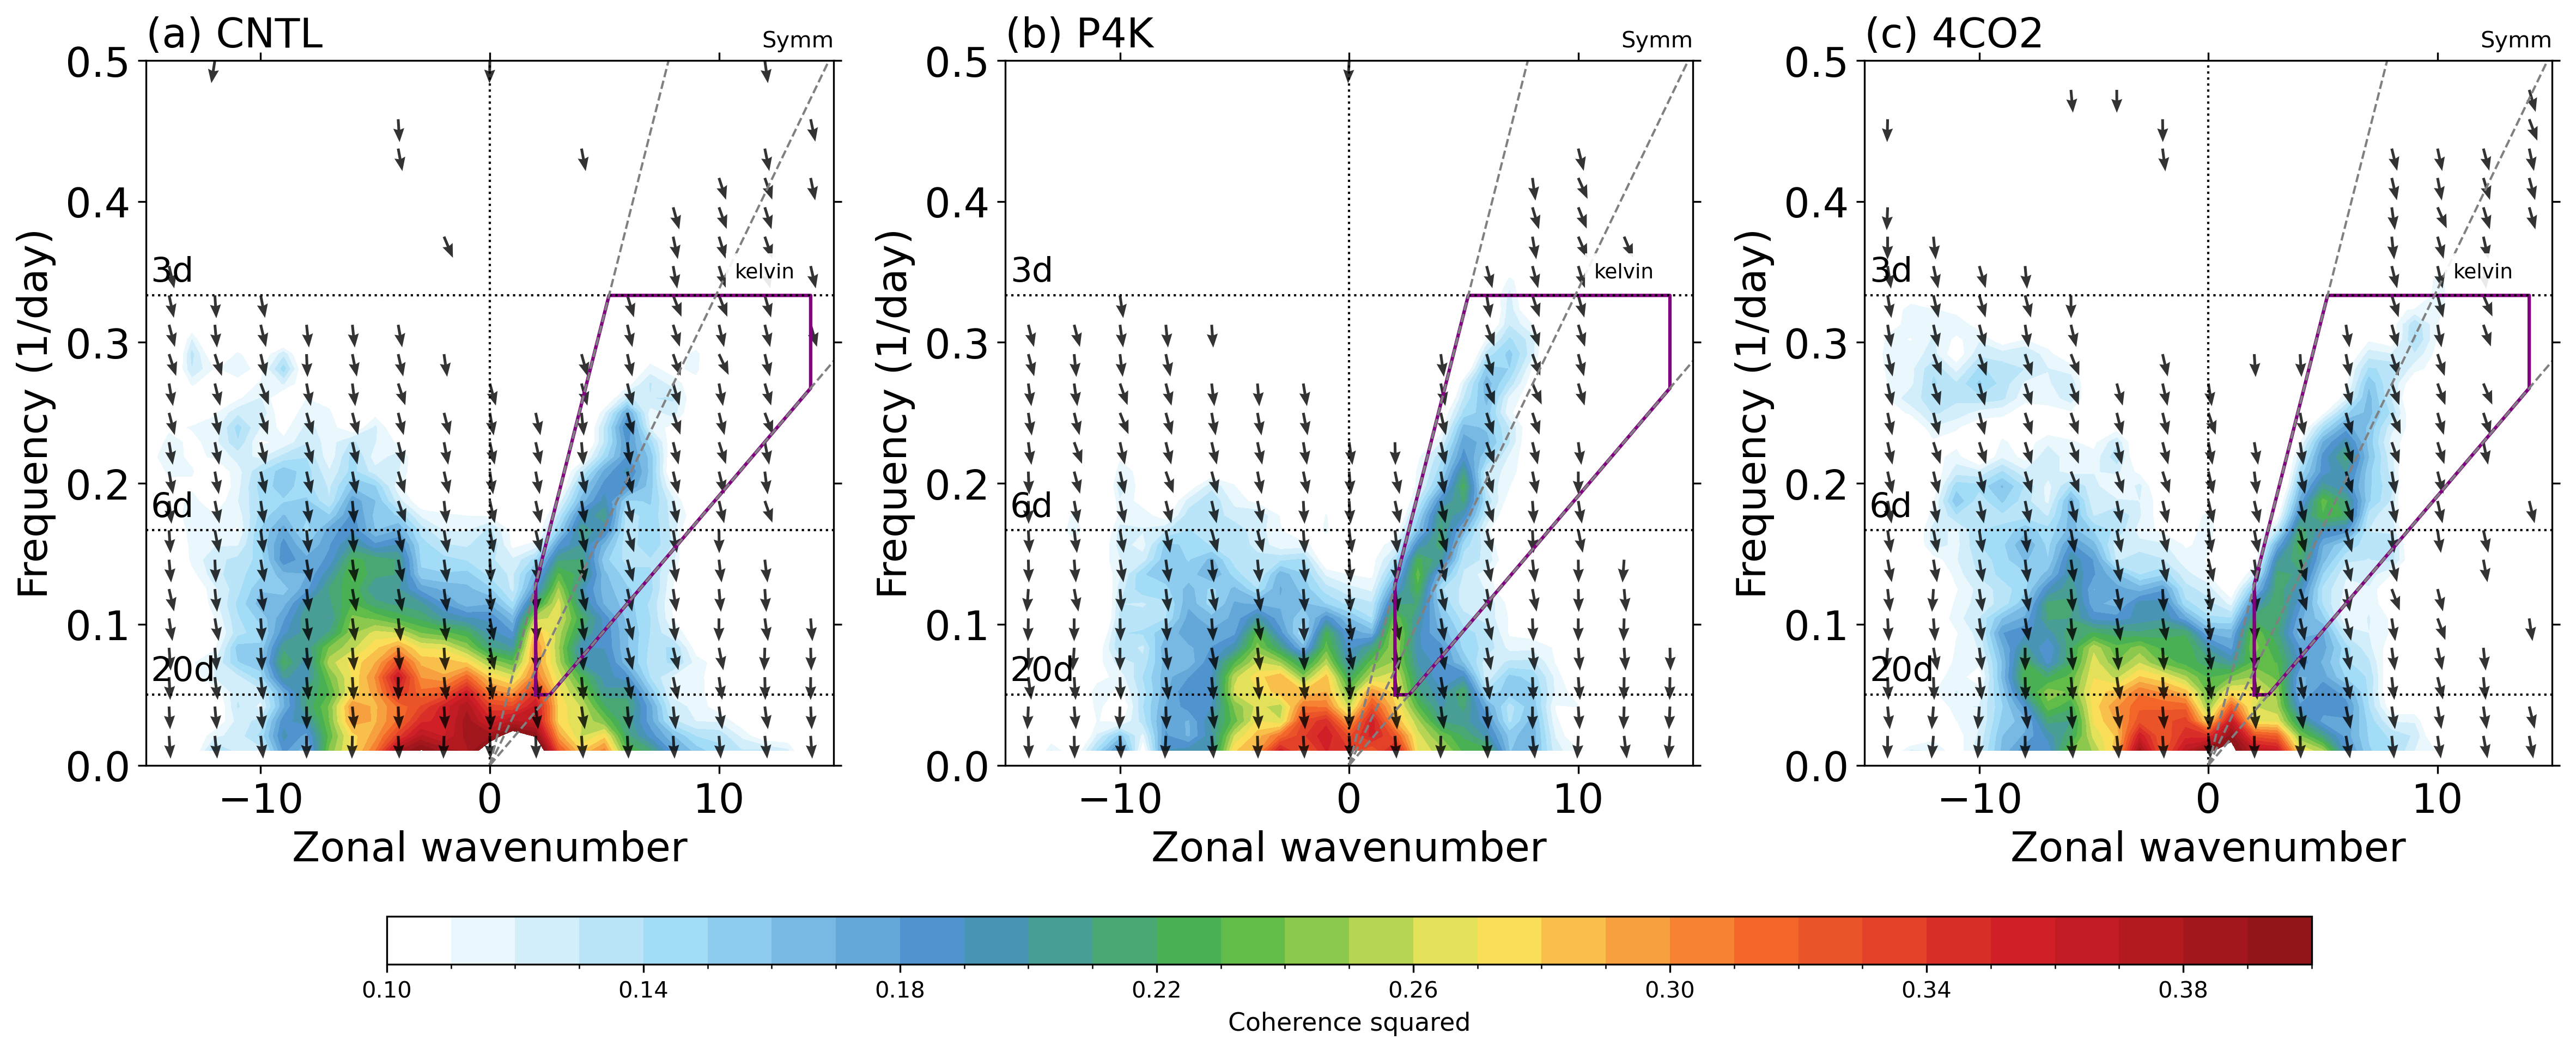

In [15]:
# ============ 绘制三个实验的交叉谱对比图 ============

s2d = 86400
re = 6371 * 1000

# 创建3个子图，横向排列
fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
plt.rcParams.update({'font.size': 10})

# 实验名称和标题
exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

# 设置coherence²阈值 - 只在显著区域显示箭头
# 使用95%置信水平的阈值
coh2_threshold = 0.05  # 可以根据显著性检验调整

for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
    plt.sca(ax)
    
    # 获取当前实验的结果
    stc = results[exp_name]['STC']
    zonalwnum = results[exp_name]['wave']
    freq = results[exp_name]['freq']
    
    # 绘制coherence squared的等高线图
    levels = np.linspace(0.1, 0.4, 31)
    contourf = stc[4].plot.contourf(
        ax=ax,
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=levels,
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )
    
    # 准备矢量场数据 - 只在coherence²高的区域显示
    # 增加采样间隔，减少箭头密度
    skip = 2 # 每隔3个点取一个
    
    # 提取数据
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc[6][::skip, ::skip].values
    v_sub = stc[7][::skip, ::skip].values
    coh2_sub = stc[4][::skip, ::skip].values
    
    # 创建掩蔽：只在coherence²超过阈值的地方显示箭头
    mask = coh2_sub < coh2_threshold
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    # 添加矢量场（相位信息）
    q = ax.quiver(
        wave_sub, freq_sub,
        u_masked, v_masked,
        scale=30, headwidth=4, headlength=5, 
        width=0.004, alpha=0.8
    )
    
    # 设置标题
    ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18,  loc='left')
    ax.set_title('Symm', fontsize=10, loc='right')
    
    # 设置坐标轴
    ax.set_ylabel('Frequency (1/day)', fontsize=18)
    ax.set_xlabel('Zonal wavenumber', fontsize=18)
    ax.set_xlim(-15, 15)
    ax.set_ylim(0, 0.5)
    
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'purple', linewidth=1.5, linestyle='solid', label='CCKW band')
    
    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re
    
    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')
    
    # 周期线
    for dd in range(len(d)):
        ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')
    
    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')
    
    # 添加"kelvin"标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
    ax.tick_params(labelsize=18, which='both', top=True, right=True)
# 添加颜色条
cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                     pad=0.15, aspect=40, shrink=0.8)
cbar.set_label('Coherence squared', fontsize=11)



# 保存图片
save_path = os.path.join(FIG_SAVE_DIR, 'cross_spectrum_comparison_all_experiments.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 图片已保存: {save_path}")

plt.show()

95%显著性水平的coherence²阈值: 0.0000
自由度: 448.06

✅ 改进版图片已保存: ./figures/cross_spectrum/cross_spectrum_comparison_with_significance.png


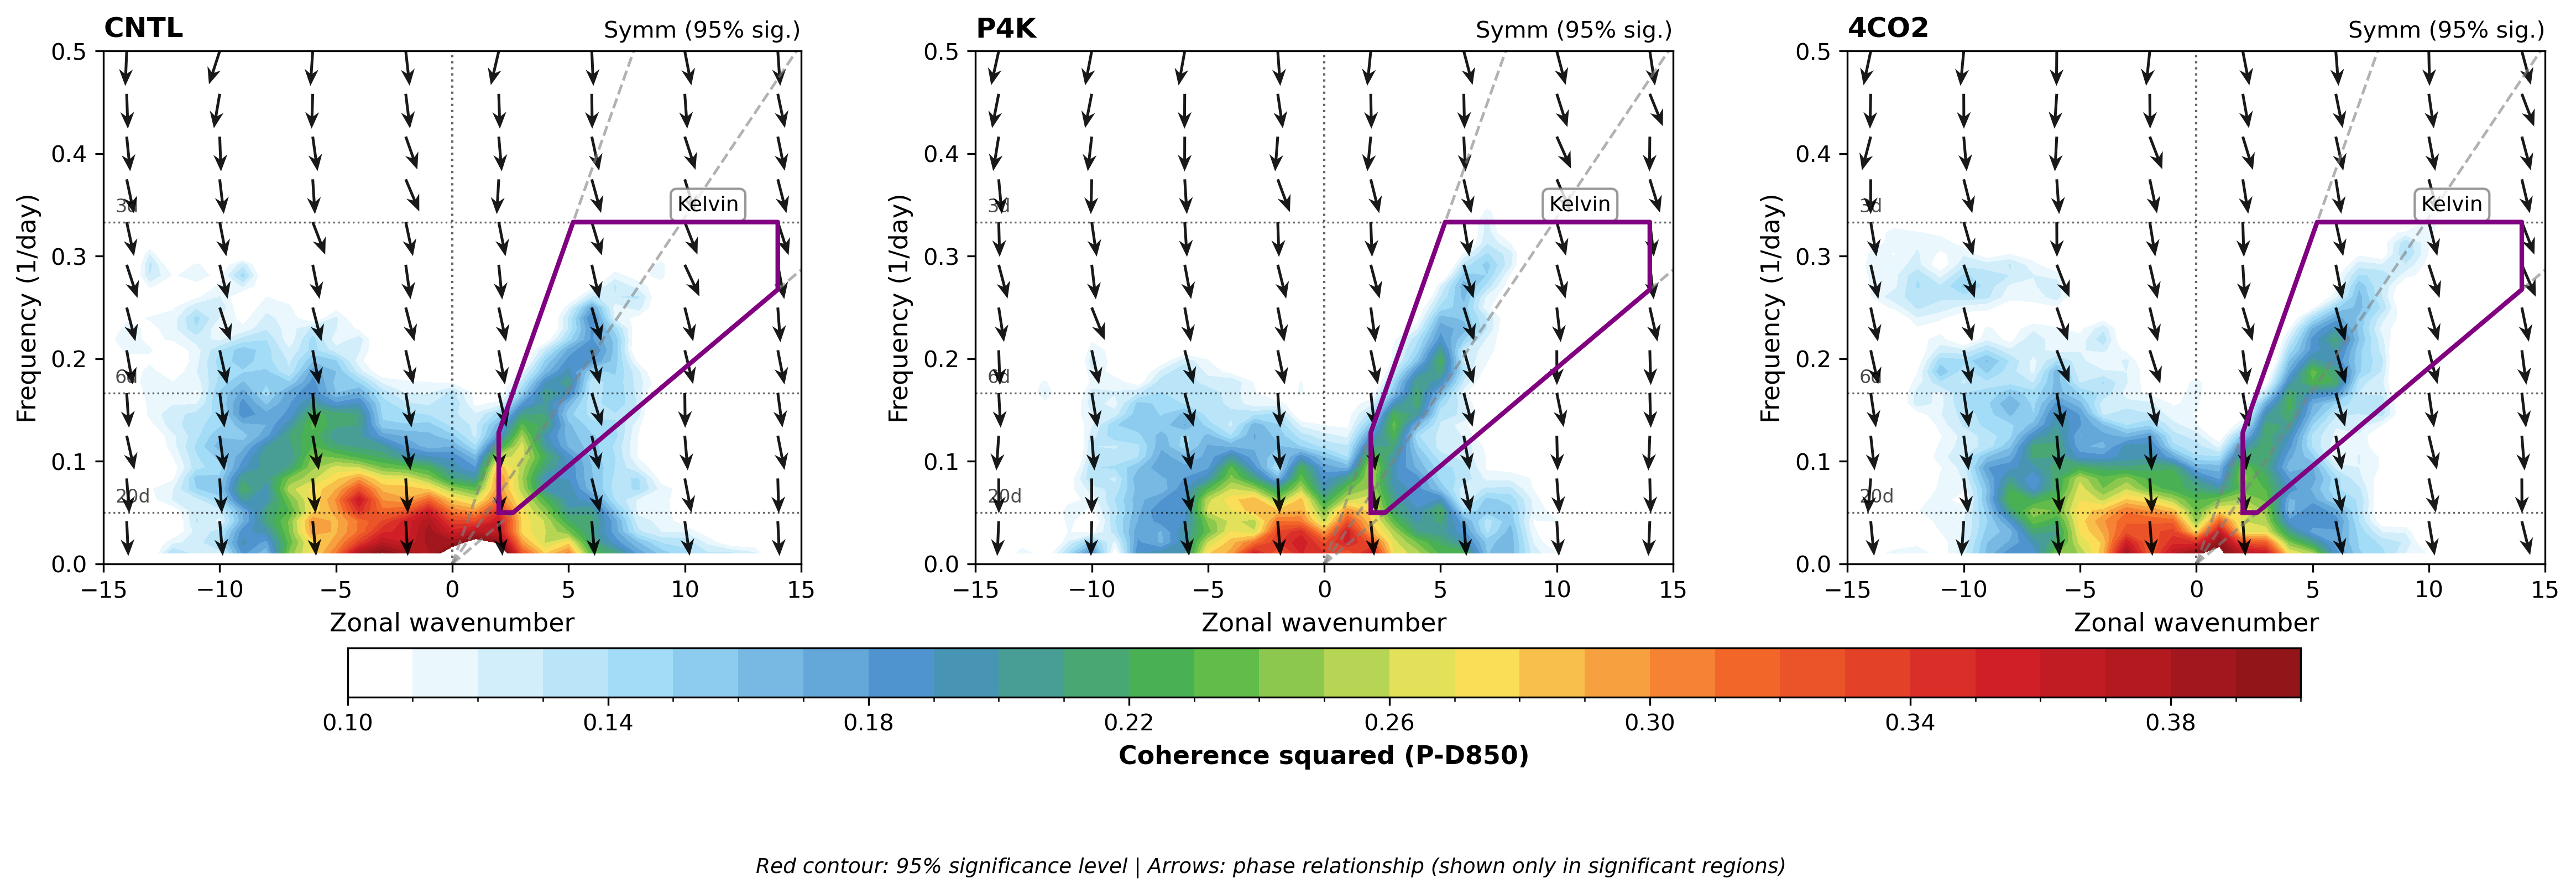

In [10]:
# ============ 绘制改进版：只显示显著区域的相位箭头 ============

s2d = 86400
re = 6371 * 1000

# 创建3个子图，横向排列
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), dpi=300)
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
plt.rcParams.update({'font.size': 10})

# 实验名称和标题
exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

# 计算95%显著性水平的coherence²阈值
# 使用第一个实验的自由度（所有实验应该相同）
dof = results['cntl']['dof']
prob_coh2 = results['cntl']['prob_coh2']
# 找到95%置信水平对应的阈值
coh2_95 = prob_coh2[4]  # 对应95%置信水平
print(f"95%显著性水平的coherence²阈值: {coh2_95:.4f}")
print(f"自由度: {dof:.2f}")

for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
    plt.sca(ax)
    
    # 获取当前实验的结果
    stc = results[exp_name]['STC']
    zonalwnum = results[exp_name]['wave']
    freq = results[exp_name]['freq']
    
    # 绘制coherence squared的等高线图
    levels = np.linspace(0.1, 0.4, 31)
    contourf = stc[4].plot.contourf(
        ax=ax,
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=levels,
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )
    
    # 添加95%显著性等值线
    cs = stc[4].plot.contour(
        ax=ax,
        levels=[coh2_95],
        colors='red',
        linewidths=2,
        linestyles='solid',
        add_labels=False
    )
    
    # 准备矢量场数据 - 只在coherence²高于95%显著性水平的区域显示
    skip = 4  # 每隔4个点取一个，减少箭头密度
    
    # 提取数据
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc[6][::skip, ::skip].values
    v_sub = stc[7][::skip, ::skip].values
    coh2_sub = stc[4][::skip, ::skip].values
    
    # 创建掩蔽：只在coherence²超过95%显著性水平的地方显示箭头
    mask = coh2_sub < coh2_95
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    # 添加矢量场（相位信息）
    q = ax.quiver(
        wave_sub, freq_sub,
        u_masked, v_masked,
        scale=20, headwidth=5, headlength=6, 
        width=0.004, alpha=0.9, color='black'
    )
    
    # 设置标题
    ax.set_title(f'{exp_title}', fontsize=12, fontweight='bold', loc='left')
    ax.set_title('Symm (95% sig.)', fontsize=10, loc='right')
    
    # 设置坐标轴
    ax.set_ylabel('Frequency (1/day)', fontsize=11)
    ax.set_xlabel('Zonal wavenumber', fontsize=11)
    ax.set_xlim(-15, 15)
    ax.set_ylim(0, 0.5)
    
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'purple', linewidth=2, linestyle='solid', 
            label='CCKW band', zorder=10)
    
    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re
    
    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':', alpha=0.6)
    
    # 周期线
    for dd in range(len(d)):
        ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=0.8, 
                linestyle=':', alpha=0.6)
        ax.text(-14.5, 1/d[dd] + 0.01, dname[dd], fontsize=8, alpha=0.7)
    
    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1.2, 
                linestyle='dashed', alpha=0.6)
    
    # 添加"kelvin"标签
    ax.text(11, 0.35, 'Kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'gray', 
                  'boxstyle': 'round,pad=0.3'})

# 添加颜色条
cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                     pad=0.12, aspect=40, shrink=0.8)
cbar.set_label('Coherence squared (P-D850)', fontsize=11, fontweight='bold')

# 添加图例说明
fig.text(0.5, 0.02, 
         'Red contour: 95% significance level | Arrows: phase relationship (shown only in significant regions)',
         ha='center', fontsize=9, style='italic')

# 保存图片
save_path = os.path.join(FIG_SAVE_DIR, 'cross_spectrum_comparison_with_significance.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 改进版图片已保存: {save_path}")

plt.show()


✅ Kelvin波段放大图已保存: ./figures/cross_spectrum/cross_spectrum_kelvin_band_focus.png


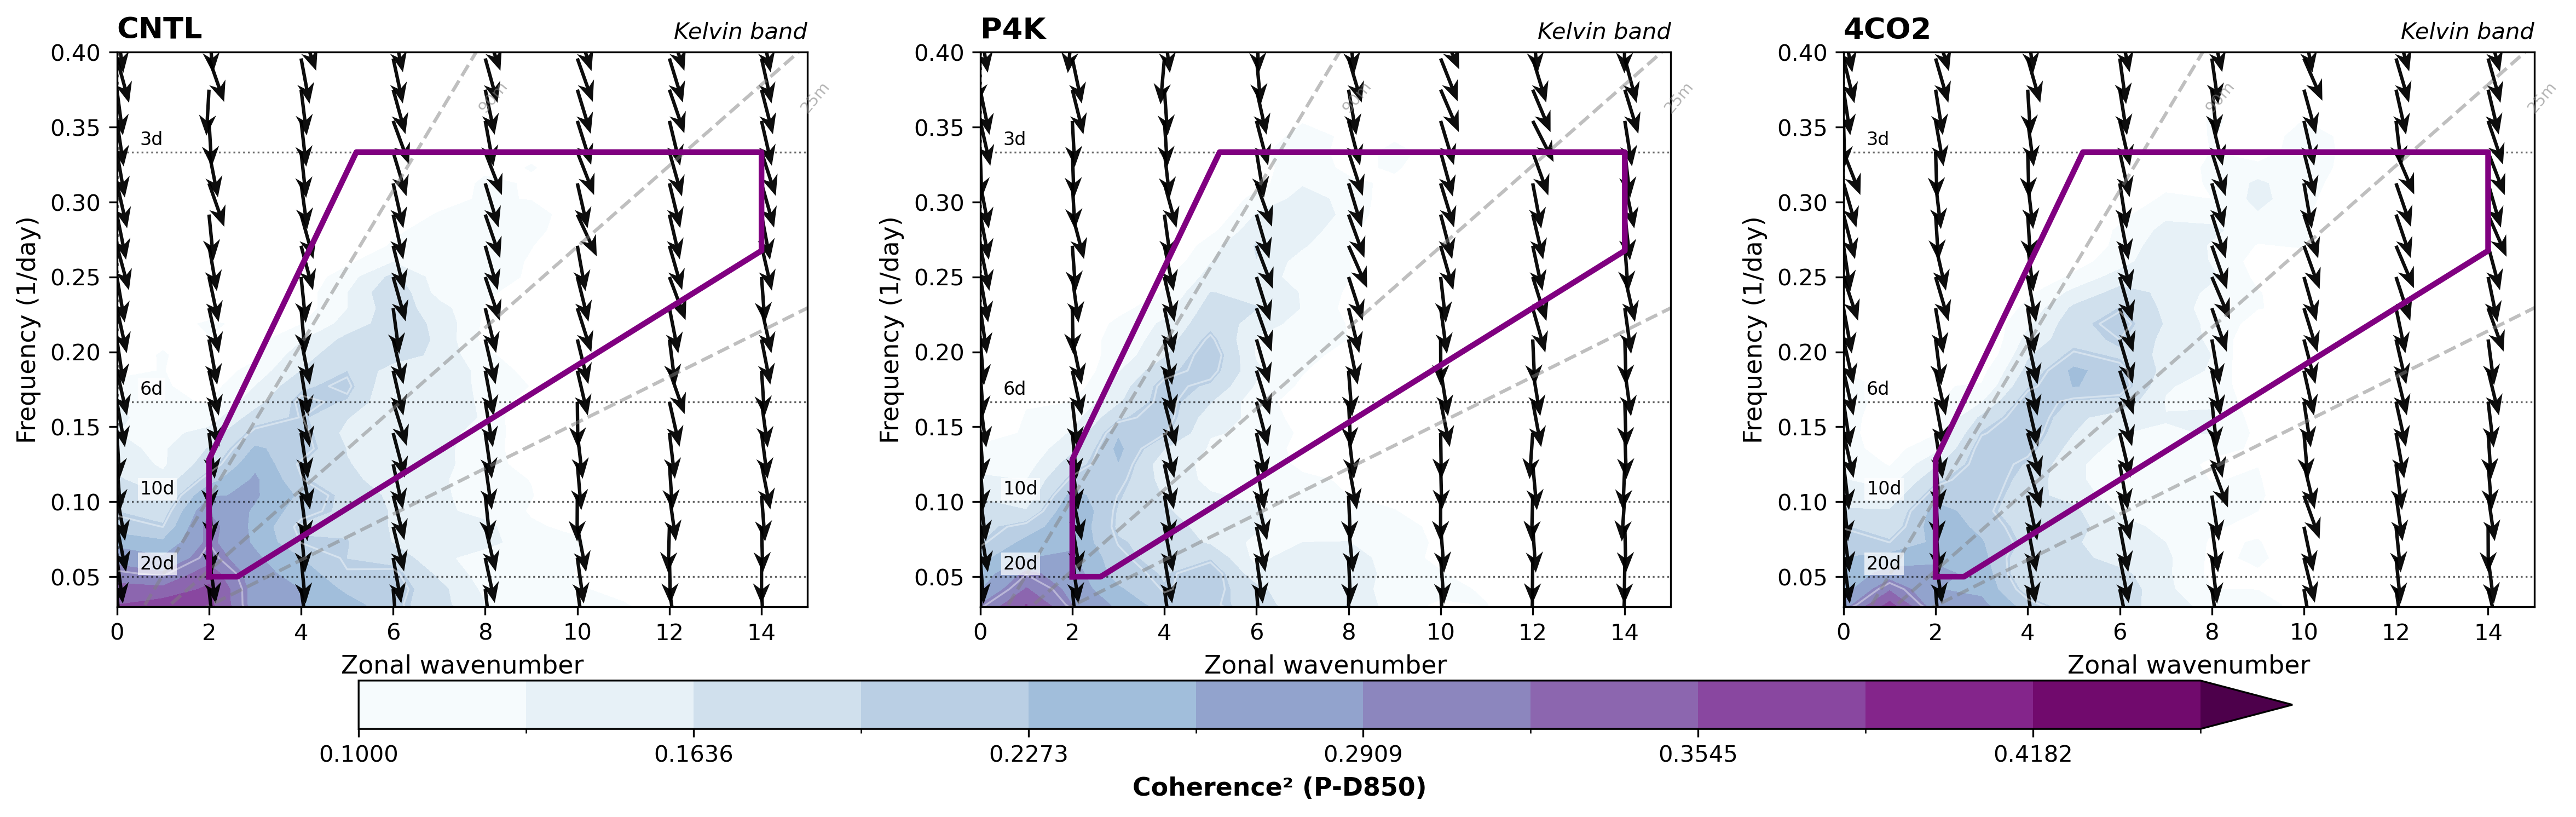

In [9]:
# ============ Kelvin波段放大图 ============

# 创建3个子图，横向排列 - 聚焦Kelvin波段
fig, axes = plt.subplots(1, 3, figsize=(16, 6), dpi=300)
plt.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.15, wspace=0.25)
plt.rcParams.update({'font.size': 10})

# 实验名称和标题
exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

# Kelvin波段的范围
wave_min, wave_max = 0, 15
freq_min, freq_max = 0.03, 0.4

for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
    plt.sca(ax)
    
    # 获取当前实验的结果
    stc = results[exp_name]['STC']
    zonalwnum = results[exp_name]['wave']
    freq = results[exp_name]['freq']
    
    # 绘制coherence squared的等高线图
    levels = np.linspace(0.1, 0.45, 12)
    contourf = stc[4].plot.contourf(
        ax=ax,
        cmap=cmaps.MPL_BuPu,
        levels=levels,
        add_colorbar=False,
        add_labels=False,
        extend='max'
    )
    
    # 添加coherence²等值线以显示结构
    stc[4].plot.contour(
        ax=ax,
        levels=[0.2, 0.3, 0.4, 0.5],
        colors='white',
        linewidths=0.8,
        alpha=0.4,
        add_labels=False
    )
    
    # 添加95%显著性等值线
    stc[4].plot.contour(
        ax=ax,
        levels=[coh2_95],
        colors='red',
        linewidths=2.5,
        linestyles='solid',
        add_labels=False
    )
    
    # 准备矢量场 - 更密集的采样以显示细节
    skip = 2
    
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc[6][::skip, ::skip].values
    v_sub = stc[7][::skip, ::skip].values
    coh2_sub = stc[4][::skip, ::skip].values
    
    # 只在显著区域显示箭头
    mask = coh2_sub < coh2_95
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    # 绘制箭头
    q = ax.quiver(
        wave_sub, freq_sub,
        u_masked, v_masked,
        scale=15, headwidth=5, headlength=6, 
        width=0.005, alpha=0.95, color='black'
    )
    
    # 设置标题
    ax.set_title(f'{exp_title}', fontsize=13, fontweight='bold', loc='left')
    ax.set_title('Kelvin band', fontsize=10, loc='right', style='italic')
    
    # 设置坐标轴 - 聚焦Kelvin波段
    ax.set_ylabel('Frequency (1/day)', fontsize=11)
    ax.set_xlabel('Zonal wavenumber', fontsize=11)
    ax.set_xlim(wave_min, wave_max)
    ax.set_ylim(freq_min, freq_max)
    
    # 绘制CCKW波段边界
    ax.plot(kw_x[0], kw_y[0], 'purple', linewidth=2.5, linestyle='solid', 
            label='CCKW band', zorder=10)
    
    # 添加参考线
    d = np.array([3, 6, 10, 20])
    dname = ['3d', '6d', '10d', '20d']
    
    # 零波数线
    ax.axvline(x=0, color='k', linewidth=1.2, linestyle=':', alpha=0.6)
    
    # 周期线
    for dd in range(len(d)):
        ax.axhline(y=1/d[dd], color='k', linewidth=0.8, linestyle=':', alpha=0.6)
        ax.text(0.5, 1/d[dd] + 0.005, dname[dd], fontsize=8, 
                bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none', 'pad': 1})
    
    # Kelvin波色散关系
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re
    
    for hh, he in enumerate(he_all):
        ax.plot([0, zwnum_goal[hh]], [0, freq_max], 'grey', 
                linewidth=1.5, linestyle='dashed', alpha=0.5)
        # 添加等效深度标签
        if zwnum_goal[hh] < wave_max:
            ax.text(zwnum_goal[hh], 0.36, f'{he}m', fontsize=7, 
                    rotation=50, alpha=0.6, color='grey')

# 添加颜色条
cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                     pad=0.10, aspect=40, shrink=0.8)
cbar.set_label('Coherence² (P-D850)', fontsize=11, fontweight='bold')


# 保存图片
save_path = os.path.join(FIG_SAVE_DIR, 'cross_spectrum_kelvin_band_focus.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Kelvin波段放大图已保存: {save_path}")

plt.show()